In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [2]:
# Displaying the dataset
df = pd.read_csv("../dataset/india_housing_prices.csv",index_col="ID")
df.tail()

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
ID,,,,,,,,,,,,,,,,,,,,,
249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,Furnished,...,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,Semi-furnished,...,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,Furnished,...,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,Unfurnished,...,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move
250000,Haryana,Gurgaon,Locality_268,Independent House,3,4313,199.69,0.05,1990,Semi-furnished,...,35,10,6,Medium,No,No,"Gym, Garden",South,Owner,Under_Construction


## Separation based on Data types 

In [3]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numerical_cols, categorical_cols

/tmp/ipykernel_23609/3654986273.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


(Index(['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
        'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools',
        'Nearby_Hospitals'],
       dtype='str'),
 Index(['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status',
        'Public_Transport_Accessibility', 'Parking_Space', 'Security',
        'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'],
       dtype='str'))

In [4]:
## Checking for null values
df.isna().sum()

State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

## Mean, Median, Mode for all Numerical Columns

In [5]:
for col in numerical_cols:
    print(f"\nColumn: {col}")
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode   :", df[col].mode().values)


Column: BHK
Mean   : 2.999396
Median : 3.0
Mode   : [1]

Column: Size_in_SqFt
Mean   : 2749.813216
Median : 2747.0
Mode   : [2098]

Column: Price_in_Lakhs
Mean   : 254.58685404
Median : 253.87
Mode   : [ 40.22  42.76 137.92 292.91 316.07 423.58]

Column: Price_per_SqFt
Mean   : 0.1305968
Median : 0.09
Mode   : [0.05]

Column: Year_Built
Mean   : 2006.520012
Median : 2007.0
Mode   : [2023]

Column: Floor_No
Mean   : 14.9668
Median : 15.0
Mode   : [20]

Column: Total_Floors
Mean   : 15.503004
Median : 15.0
Mode   : [24]

Column: Age_of_Property
Mean   : 18.479988
Median : 18.0
Mode   : [2]

Column: Nearby_Schools
Mean   : 5.49986
Median : 5.0
Mode   : [1]

Column: Nearby_Hospitals
Mean   : 5.498016
Median : 5.0
Mode   : [4]


In [6]:
## City wise mean price of a property

In [7]:
df.groupby("City")["Price_in_Lakhs"].mean().sort_values(ascending=False)

City
Bangalore         258.456639
Surat             258.080467
Kochi             257.415221
Gaya              257.053391
Mangalore         256.920925
Dehradun          256.890115
Mysore            256.848172
Chennai           256.830172
Hyderabad         256.594051
Coimbatore        256.504745
Bhopal            256.498896
Pune              256.495661
Noida             256.287206
Lucknow           256.212431
Vishakhapatnam    255.772442
Nagpur            255.532012
Indore            255.413825
Jaipur            255.246241
Bhubaneswar       254.902173
Faridabad         254.862393
Vijayawada        254.643766
Ranchi            254.624529
Warangal          254.475113
Durgapur          254.100152
Gurgaon           254.027549
Jodhpur           253.947906
Kolkata           253.914897
Ahmedabad         253.586827
Raipur            253.482416
Dwarka            253.454299
Ludhiana          253.159636
Guwahati          252.992710
Patna             252.794673
Jamshedpur        252.626185
Silchar  

In [8]:
df.groupby("Property_Type")["Price_in_Lakhs"].agg(["mean","median","count"])

,mean,median,count
Property_Type,,,
Apartment,254.622116,254.020,82956
Independent House,255.374150,255.040,83300
Villa,253.768802,252.535,83744


In [9]:
df["Amenity_Count"] = df["Amenities"].apply(lambda x: len(x.split(",")))
df.groupby("Amenity_Count")["Price_in_Lakhs"].mean()

Amenity_Count
1    254.751700
2    253.968325
3    254.627492
4    254.664747
5    254.919710
Name: Price_in_Lakhs, dtype: float64

In [10]:
cols = [
    "Price_in_Lakhs",
    "Size_in_SqFt",
    "BHK",
    "Age_of_Property",
    "Floor_No",
    "Total_Floors",
    "Nearby_Schools",
    "Nearby_Hospitals"
]
df[cols].agg(["min", "max"])

,Price_in_Lakhs,Size_in_SqFt,BHK,Age_of_Property,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals
min,10.0,500,1,2,0,1,1,1
max,500.0,5000,5,35,30,30,10,10


In [11]:
state_price_extremes = df.groupby("State")["Price_in_Lakhs"].agg(["max", "min"])

state_price_extremes

,max,min
State,,
Andhra Pradesh,499.97,10.04
Assam,499.89,10.06
Bihar,499.96,10.16
Chhattisgarh,499.91,10.02
Delhi,499.97,10.06
Gujarat,499.99,10.04
Haryana,499.99,10.00
Jharkhand,499.99,10.06
Karnataka,499.94,10.06


In [12]:
df[df["Floor_No"] > df["Total_Floors"]]

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,Amenity_Count
ID,,,,,,,,,,,,,,,,,,,,,
1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,...,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,5
2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,...,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,5
5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,...,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,5
6,West Bengal,Durgapur,Locality_246,Apartment,4,3500,135.28,0.04,2020,Semi-furnished,...,7,7,Low,Yes,Yes,"Playground, Clubhouse",West,Broker,Ready_to_Move,2
7,Tamil Nadu,Coimbatore,Locality_254,Independent House,3,4826,318.12,0.07,2016,Furnished,...,3,6,High,No,Yes,"Clubhouse, Garden, Playground",North,Builder,Under_Construction,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249990,Delhi,Dwarka,Locality_208,Villa,1,4802,245.29,0.05,1992,Unfurnished,...,8,5,Low,No,Yes,"Gym, Pool, Garden",North,Broker,Ready_to_Move,3
249991,Jharkhand,Ranchi,Locality_403,Villa,3,1261,307.44,0.24,2019,Semi-furnished,...,10,9,Medium,Yes,No,"Clubhouse, Playground",East,Owner,Under_Construction,2
249993,Delhi,Dwarka,Locality_83,Apartment,1,3408,225.27,0.07,2003,Furnished,...,9,4,Low,Yes,Yes,"Pool, Playground, Gym, Garden, Clubhouse",East,Builder,Ready_to_Move,5


## Analysis of Columns
**Target Column** - Price_per_SqFt  
**Numerical Columns**  
*(int64)*
1. ID              : Should be removed
2. BHK             : Data ranges from 1 - 5 all having median price similar
3. Size_in_SqFt    : Debatable
4. Year_Built      : Can be removed as we already have age of property
5. Floor_No        : issue
6. Total_Floors    : issue
7. Age_of_Property : Range from 2 - 35 whole numbers
8. Nearby_Schools  : Data range from 1 - 10
9. Nearby_Hospitals: Data range from 1 - 10

*(float64)*
1. Price_in_Lakhs  : Target Column
2. Price_in_SqFt   : Can be removed as we already have price_in_Lakhs

# Categorical Columns Analysis

In [13]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

State
Odisha            12681
Tamil Nadu        12629
West Bengal       12622
Gujarat           12578
Delhi             12552
Telangana         12539
Maharashtra       12533
Punjab            12516
Uttar Pradesh     12508
Uttarakhand       12501
Assam             12496
Kerala            12487
Jharkhand         12480
Andhra Pradesh    12462
Chhattisgarh      12456
Madhya Pradesh    12451
Karnataka         12424
Rajasthan         12402
Bihar             12369
Haryana           12314
Name: count, dtype: int64


City
Coimbatore        6461
Ahmedabad         6411
Silchar           6404
Durgapur          6387
Cuttack           6358
Vijayawada        6344
Jamshedpur        6335
Bhubaneswar       6323
New Delhi         6306
Kochi             6305
Ludhiana          6295
Bhopal            6284
Hyderabad         6273
Noida             6271
Haridwar          6267
Warangal          6266
Bilaspur          6263
Dwarka            6246
Lucknow           6237
Kolkata           6235
Dehradun          623

In [14]:
cat_cols_b = [
    "Property_Type",
    "Furnished_Status",
    "Public_Transport_Accessibility",
    "Parking_Space",
    "Security",
    "Facing",
    "Owner_Type",
    "Availability_Status"
]

In [15]:
category_dict = {}

for col in cat_cols_b:
    category_dict[col] = df[col].unique().tolist()

category_dict

{'Property_Type': ['Apartment', 'Independent House', 'Villa'],
 'Furnished_Status': ['Furnished', 'Unfurnished', 'Semi-furnished'],
 'Public_Transport_Accessibility': ['High', 'Low', 'Medium'],
 'Parking_Space': ['No', 'Yes'],
 'Security': ['No', 'Yes'],
 'Facing': ['West', 'North', 'South', 'East'],
 'Owner_Type': ['Owner', 'Builder', 'Broker'],
 'Availability_Status': ['Ready_to_Move', 'Under_Construction']}

**Categorical Columns**
1. State                              : 20 different states (Target encoding)
2. City                               : 42 different cities (Target encoding)
3. Locality                           : high cardinality (500), one hot, ordinal encoding not much effective (frequency encoding) 
4. Property_Type                      : (3 types) (one-hot encoding)
5. Furnished_Status                   : (3 types) hiarchical (ordinal encoding)
6. Public_Transport_Accessibility     : (3 types) hiarchical (ordinal encoding)
7.  Parking_Space                     : Yes/No (binary)
8.  Security                          : Yes/No (binary)
9.  Amenities                         : can be changed to numerical [5 amenities]
10.  Facing                           : 4 directions (ordinal encoding)
11.  Owner_Type                       : Broker builder owner can be dropped
12.  Availability_Status              : under construction ,ready (ordinal encoding)

## Checking for outliers in numerical data using box plot

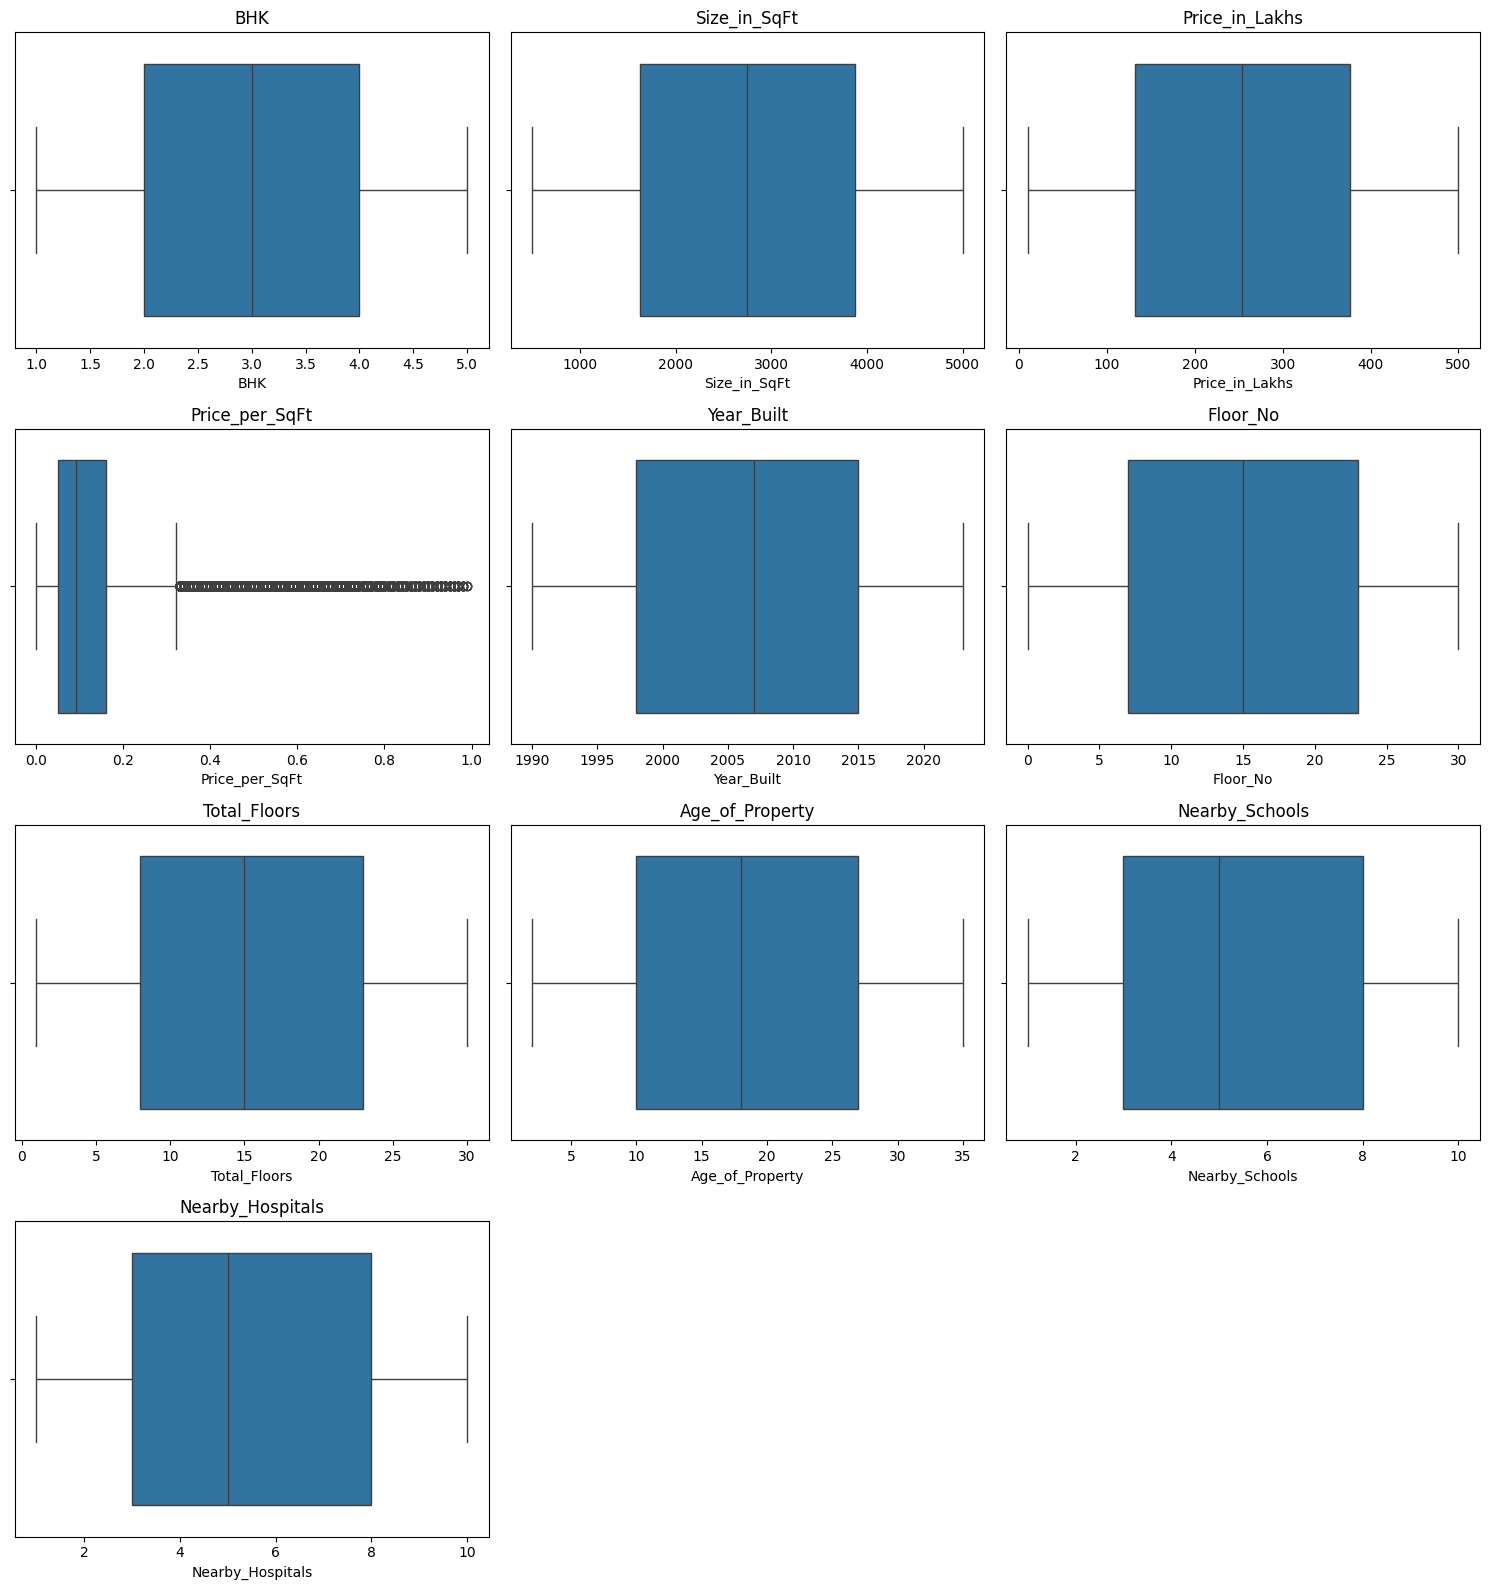

In [30]:
import math
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()